# Matplotlib 
# 3. Visual Reconnaissance

Tables in **Pandas** are great for computers, but the human brain is built for image processing. To find trends, anomalies, or relationships in data, we must `visualize` it.

**Matplotlib** is the fundamental library for creating charts in Python. We will learn the professional **Object-Oriented (OO)** approach, which gives us absolute control over every pixel of the chart and we will use it to create applications in Streamlit.

**Overview & Roadmap:**
* Difference between `Figure` (canvas) and `Axes` (chart).
* Plot development over time (Line Plot).
* Search for relationships between data (Scatter Plot).
* Compare supplies (Bar Chart).
* Export charts to reports.

## 3.0 Data Initialization (Simulation)

First, we must import the library. The standard alias shortcut for Matplotlib pyplot in the community is `plt`.

In [1]:
import matplotlib.pyplot as plt

*The Huygens probe has just entered the atmosphere of the moon Titan. We are receiving telemetry.*

In [ ]:
import pandas as pd
import numpy as np

# Simulation of descent and measurement on the surface of Titan (60 minutes)
time_log = np.arange(1, 61) # generating values 1-60
data_titan = {
    'minute': time_log,
    'surface_temp_c': np.random.uniform(-181, -178, 60), # Titan is freezing (-179°C),
    'wind_speed_kmh': np.linspace(120, 5, 60) + np.random.normal(0, 5, 60), # Wind decreases towards the surface
    'methane_lake_level_m': np.random.uniform(50, 52, 60) # Level of Lake Ligeia Mare
}
# .uniform = all values within the interval have the same chance
# .normal = greater chance is for values around the center of the interval (Gaussian curve)

df_titan = pd.DataFrame(data_titan)

print("Telemetry from the Saturn-Titan system loaded.")
print(df_titan.head())

Telemetrie ze systému Saturn-Titan načtena.
   minute  surface_temp_c  wind_speed_kmh  methane_lake_level_m
0       1     -178.925327      128.155677             50.344507
1       2     -180.709714      120.974805             50.577830
2       3     -179.220467      112.359060             50.179441
3       4     -178.100564      115.616204             51.351670
4       5     -179.216823      108.678892             51.919056


## 3.1 Painter and Canvas (OOP Approach)
The standard approach uses a `"quick" style` (pyplot) for generating charts. We will learn the `"professional" style` (using fig & ax), which we will need for our dashboards.

**PYPLOT (standard):**
- we use plt.plot(), plt.title()
- we rely on Python knowing which chart is currently "active" - in a complex application, this can easily break

**OO (Object-Oriented):**
- you create objects: `Canvas (Figure) and Chart (Axes)`.
- then we call methods directly on these objects
- we have full control: "Plot this data into chart A and this data into chart B."

Object Hierarchy:
- `Figure (fig):` The entire canvas or easel. It can contain one or more charts (a holder for charts)
- `Axes (ax):` A specific chart (area with X and Y axes) into which we draw data (we work with this most often)

<class 'matplotlib.figure.Figure'>
<class 'matplotlib.axes._axes.Axes'>


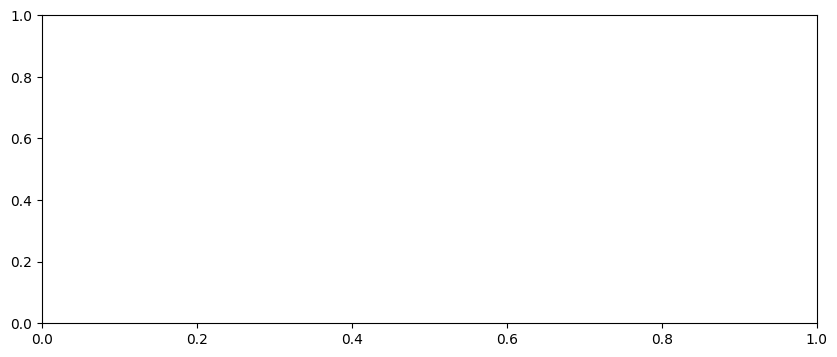

In [ ]:
# Creating objects (Constructor) of an empty canvas (Figure) and one chart (Axes)
# figsize=(width, height) in inches
fig, ax = plt.subplots(figsize=(10, 4))

# Now we have an empty 'ax' into which we can draw
print(type(fig))
print(type(ax))

## 3.2 Line Plot - Descent Profile

A basic tool for tracking trends. We will look at how the wind speed decreased during the probe's descent through the atmosphere.

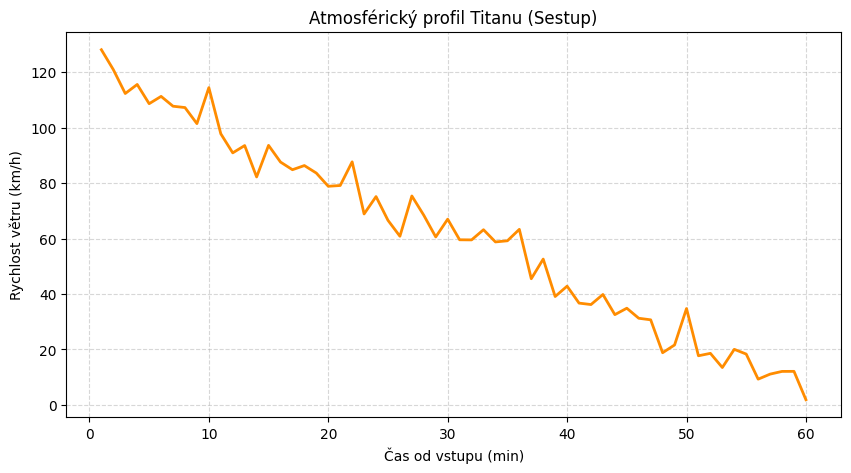

In [ ]:
# 1. Create canvas and axes
fig, ax = plt.subplots(figsize=(10, 5))

# 2. Plot data into 'ax'
# ax.plot(X_axis, Y_axis, arguments...)
# we choose the color 'orange' because Titan's atmosphere is orange
ax.plot(df_titan['minute'], df_titan['wind_speed_kmh'], color='darkorange', linewidth=2, label='Wind Speed')

# 3. Set labels for chart title and axis labels
ax.set_title('Titan Atmospheric Profile (Descent)')
ax.set_xlabel('Time since entry (min)')
ax.set_ylabel('Wind Speed (km/h)')

# 4. Set grid for better readability
ax.grid(True, linestyle='--', alpha=0.5)

# 5. Display chart
plt.show()

## 3.3 Multiple Curves and Legend

We often need to compare two quantities. Let's look at the stability of temperature and the methane lake level. We can send multiple data series into a single **ax** object.

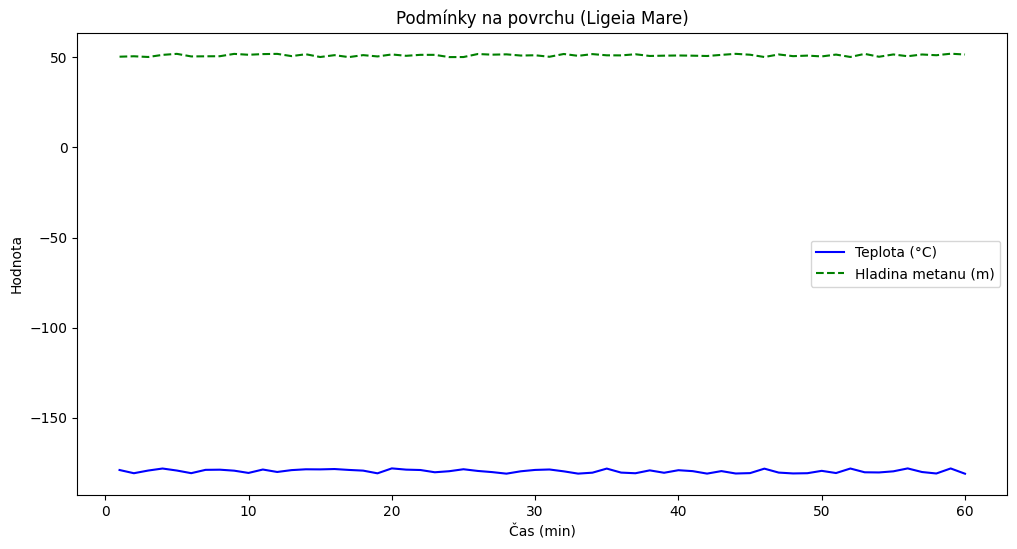

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# First curve (Temperature)
ax.plot(df_titan['minute'], df_titan['surface_temp_c'], color='blue', label='Temperature (°C)')

# Second curve (Methane Level) - for illustration, we display it in the same chart
# (In reality, they usually have different Y axes, but for syntax demonstration, it's enough)
ax.plot(df_titan['minute'], df_titan['methane_lake_level_m'], color='green', linestyle='--', label='Methane Level (m)')

# Chart settings
ax.set_title('Surface Conditions (Ligeia Mare)')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Value')

# Display legend (uses 'labels' defined in plot)
ax.legend()

plt.show()

## 3.4 Scatter Plot - Searching for Anomalies

Is there a relationship between wind gusts and temperature measurement fluctuations? A scatter plot will show us the distribution of measurements.

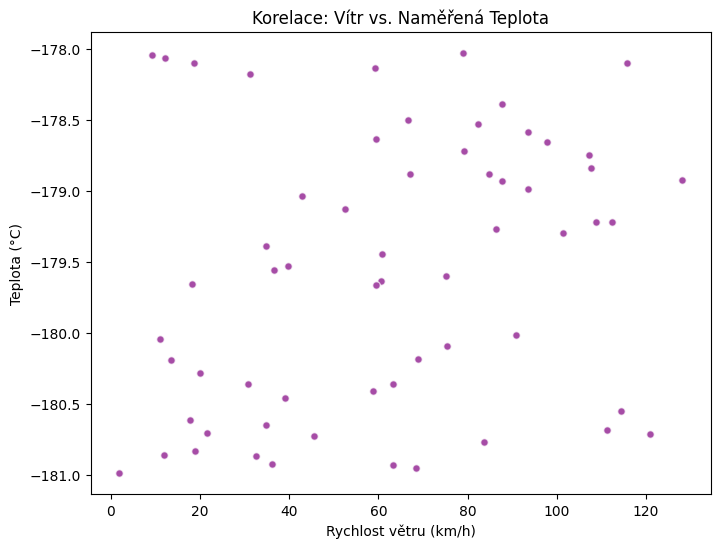

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot: X = Wind, Y = Temperature
# We are looking to see if strong wind cools down the sensor (Wind Chill)
ax.scatter(df_titan['wind_speed_kmh'], df_titan['surface_temp_c'], c='purple', s=30, alpha=0.7, edgecolors='white')

ax.set_title('Correlation: Wind vs. Measured Temperature')
ax.set_xlabel('Wind Speed (km/h)')
ax.set_ylabel('Temperature (°C)')

plt.show()

## 3.5 Bar Chart - Chemical Analysis

The probe took a sample from the "soil". The spectrometer determined the chemical composition. The object-oriented approach is great for annotations (value labels) because we know exactly which object we are working with.

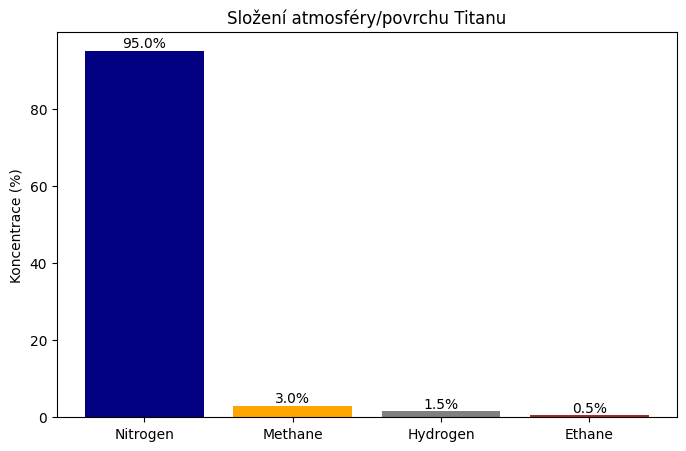

In [ ]:
# Data from mass spectrometer
elements = ['Nitrogen', 'Methane', 'Hydrogen', 'Ethane']
composition_pct = [95, 3.0, 1.5, 0.5] # Percentage representation

fig, ax = plt.subplots(figsize=(8, 5))

# Bar chart
bars = ax.bar(elements, composition_pct, color=['navy', 'orange', 'grey', 'brown'])

ax.set_title('Atmosphere/Surface Composition of Titan')
ax.set_ylabel('Concentration (%)')

# Adding value above columns
ax.bar_label(bars, fmt='%.1f%%')

plt.show()

## 3.6 Output Export

We must send the chemical composition chart to Earth in the main report.

In [ ]:
# Saving the current 'fig' to a file
# dpi = dots per inch (quality), bbox_inches='tight' crops white margins
fig.savefig('titan_spectrometry_report.png', dpi=300, bbox_inches='tight')

print("Chart encoded and sent (saved as 'titan_spectrometry_report.png')")

## Practise - Simulator Training

### practise I: Temperature Curve
The Huygens probe sent temperature data during descent. Plot a simple chart so we can see how the temperature changes over time.

**Assignment:**
- we will use data from Titan:

    ```python
    time_log = np.arange(1, 61)
    data_titan = {
        'minute': time_log,
        'surface_temp_c': np.random.uniform(-181, -178, 60),
        'wind_speed_kmh': np.linspace(120, 5, 60) + np.random.normal(0, 5, 60),
        'methane_lake_level_m': np.random.uniform(50, 52, 60)
    }

    df_titan = pd.DataFrame(data_titan)
    ```

- Plot the temperature `surface_temp_c` dependent on time (minute) using a line chart.
- Set the line color to blue and add a grid.
- Name the axes and the chart.

---

## practise II: Lake Levels
Radar measured the depth of the three largest methane lakes on Titan. We will compare them graphically.

**Assignment:**

- we will use data from Titan:

    ```python
    lakes = ['Kraken Mare', 'Ligeia Mare', 'Punga Mare']
    depths = [160, 170, 120] # in meters
    ```

- Plot a bar chart.
- Represent each column with a different color.

## Homework (Project: Mars)
In the previous phase (last lesson), we analyzed data about the base environment.

**Mission:** Now we must turn these numbers into clear charts for commanding officers so they can decide on the safety of extravehicular activities (EVA).

0. Input Data: Run the following cell. It will load (simulate) already processed data from the previous mission phase for you.

### Data State Reconstruction from Previous Lesson
```python
# --- DATA PREPARATION (run first) ---
import pandas as pd
import numpy as np

dates = pd.date_range(start='2035-01-01', periods=100, freq='D')
data = {
    'date': dates,
    'avg_temp_c': np.random.uniform(-80, -20, 100),
    'pressure_pa': np.random.uniform(600, 650, 100),
    'radiation_rem': np.random.uniform(0.1, 0.5, 100) + np.sin(np.linspace(0, 10, 100)) * 0.1, # Sine wave added for a nicer chart
    'solar_flare': np.random.choice([True, False], 100, p=[0.15, 0.85])
}
df_mars_processed = pd.DataFrame(data)

# Calculating rolling average
df_mars_processed['radiation_trend'] = df_mars_processed['radiation_rem'].rolling(window=7).mean()

print("Phase 2 data loaded.")
print(df_mars_processed.head())
```

### Assignment:

We will use the prepared DataFrame `df_mars_processed`.

- Chart 1: Radiation Situation (Line Plot):

    - Create a chart (fig, ax) that displays radiation development over time.

    - Plot raw radiation `radiation_rem` as a thin, semi-transparent line (e.g., gray, alpha=0.5).

    - In the same chart, plot the trend `radiation_trend` as a distinct (thicker) red line.

    - Add a grid, axis labels, and a legend.

- Chart 2: Atmospheric Analysis (Scatter Plot):

    - Verify if a visual relationship exists between pressure and temperature.

    - Create a scatter plot where `pressure_pa` is on the X-axis and `avg_temp_c` temperature is on the Y-axis.

    - Set the dot color to dark blue and slight transparency.

- Export:

    - Save the chart with radiation using code as image `mars_radiation_status.png`.

---
#### © Jiří Svoboda (George Freedom)
- Web: https://GeorgeFreedom.com
- LinkedIn: https://www.linkedin.com/in/georgefreedom/
- Let's talk: https://cal.com/georgefreedom